In [19]:
import pandas as pd
import numpy as np
import ast
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import MultiLabelBinarizer, normalize
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv("cleaned_movies_metadata.csv")
df = df.reset_index(drop=True)

print("Data shape:", df.shape)

Data shape: (5363, 24)


In [28]:
def parse_genres(x):
    if pd.isna(x):
        return []
    try:
        genres = ast.literal_eval(x)

        if not isinstance(genres, list):
            return []

        return [
            g["name"]
            for g in genres
            if isinstance(g, dict) and "name" in g
        ]

    except Exception:
        return []

df["genre_list"] = df["genres"].apply(parse_genres)
df[["title", "genres", "genre_list"]].head()

,title,genres,genre_list
0,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","[Animation, Comedy, Family]"
1,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[Adventure, Fantasy, Family]"
2,Heat,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...","[Action, Crime, Drama, Thriller]"
3,GoldenEye,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...","[Adventure, Action, Thriller]"
4,Cutthroat Island,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[Action, Adventure]"


In [29]:
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df["genre_list"])

print("Original genre matrix shape:", genre_matrix.shape)
print("Genre classes:", mlb.classes_)


# TruncatedSVD 
n_components = 10
n_components = min(n_components, genre_matrix.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=42)
genre_matrix_svd = svd.fit_transform(genre_matrix)

print("SVD genre matrix shape:", genre_matrix_svd.shape)
print("Explained variance ratio:", svd.explained_variance_ratio_.sum())

# normalize
genre_matrix_svd_norm = normalize(genre_matrix_svd)

tag_similarity_svd = cosine_similarity(genre_matrix_svd_norm).astype(np.float32)

print("Tag similarity matrix shape:", tag_similarity_svd.shape)

Original genre matrix shape: (5363, 20)
Genre classes: ['Action' 'Adventure' 'Animation' 'Comedy' 'Crime' 'Documentary' 'Drama'
 'Family' 'Fantasy' 'Foreign' 'History' 'Horror' 'Music' 'Mystery'
 'Romance' 'Science Fiction' 'TV Movie' 'Thriller' 'War' 'Western']
SVD genre matrix shape: (5363, 10)
Explained variance ratio: 0.8091954679660167
Tag similarity matrix shape: (5363, 5363)


Saved: tag_similarity_svd.pkl
Saved: movie_index_mapping.csv


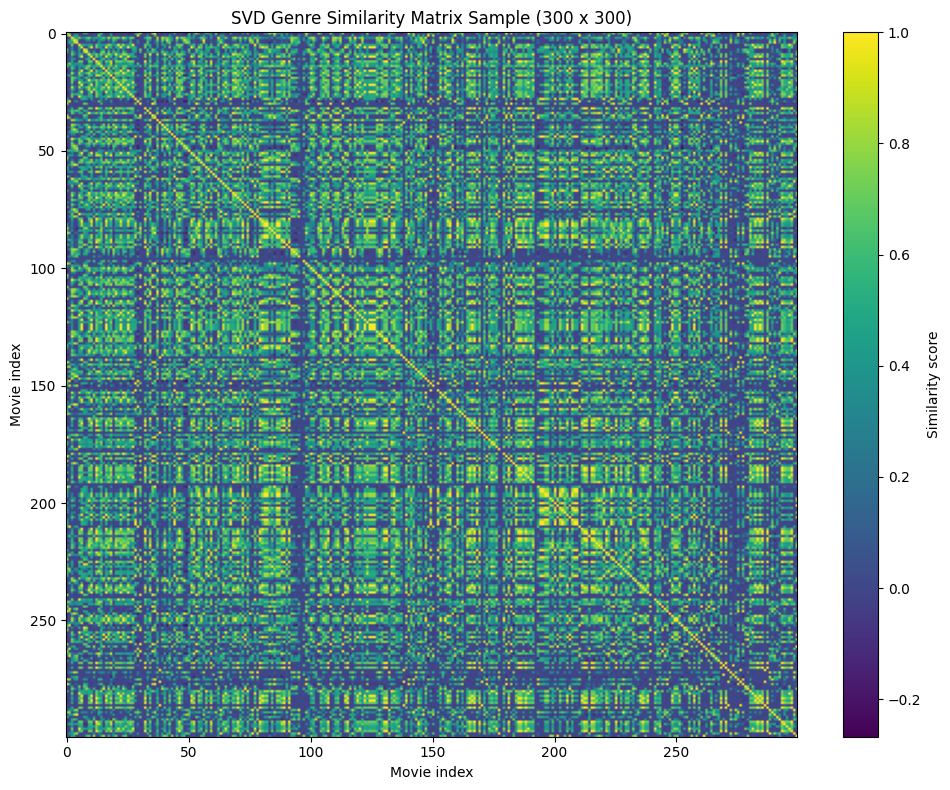

In [32]:
with open("tag_similarity_svd.pkl", "wb") as f:
    pickle.dump(tag_similarity_svd, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved: tag_similarity_svd.pkl")

movie_index_mapping = df[["id", "title"]].copy()
movie_index_mapping.insert(0, "matrix_idx", df.index)

movie_index_mapping.to_csv("movie_index_mapping.csv", index=False)

print("Saved: movie_index_mapping.csv")

# 似乎有点太密集了，会卡很久，所以图片只截取300的局部
sample_size = 300

plt.figure(figsize=(10, 8))
plt.imshow(tag_similarity_svd[:sample_size, :sample_size], aspect="auto")
plt.colorbar(label="Similarity score")
plt.title(f"SVD Genre Similarity Matrix Sample ({sample_size} x {sample_size})")
plt.xlabel("Movie index")
plt.ylabel("Movie index")
plt.tight_layout()
plt.savefig("tag_similarity_svd_sample_5363.png", dpi=300)
plt.show()